# IMT 573 - Final Examination


Points: 100

Name: Brittany Boubel

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

Brittany Boubel

11/30/25




For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset. 

In [219]:
affairs = sm.datasets.fair.load_pandas().data
print(sm.datasets.fair.NOTE)

::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

In [220]:
affairs.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [221]:
# Shows the structure of the dataset
affairs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_marriage    6366 non-null   float64
 1   age              6366 non-null   float64
 2   yrs_married      6366 non-null   float64
 3   children         6366 non-null   float64
 4   religious        6366 non-null   float64
 5   educ             6366 non-null   float64
 6   occupation       6366 non-null   float64
 7   occupation_husb  6366 non-null   float64
 8   affairs          6366 non-null   float64
dtypes: float64(9)
memory usage: 447.7 KB


In [222]:
# Summarizes all numeric variables in the dataset
affairs.describe()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
count,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000
mean,4.109645,29.082862,9.009425,1.396874,2.426170,14.209865,3.424128,3.850141,0.705374
std,0.961430,6.847882,7.280120,1.433471,0.878369,2.178003,0.942399,1.346435,2.203374
min,1.000000,17.500000,0.500000,0.000000,1.000000,9.000000,1.000000,1.000000,0.000000
25%,4.000000,22.000000,2.500000,0.000000,2.000000,12.000000,3.000000,3.000000,0.000000
50%,4.000000,27.000000,6.000000,1.000000,2.000000,14.000000,3.000000,4.000000,0.000000
75%,5.000000,32.000000,16.500000,2.000000,3.000000,16.000000,4.000000,5.000000,0.484848
max,5.000000,42.000000,23.000000,5.500000,4.000000,20.000000,6.000000,6.000000,57.599991


In [223]:
# Calculates the average number of children
avg_children = affairs['children'].mean()
avg_children

np.float64(1.3968740182218033)

In [224]:
# Calculates the average age of respondents
avg_age = affairs['age'].mean()
avg_age

np.float64(29.082862079798932)

In [225]:
# Checks for missing values in the dataset
affairs.isna().sum()

rate_marriage      0
age                0
yrs_married        0
children           0
religious          0
educ               0
occupation         0
occupation_husb    0
affairs            0
dtype: int64

The dataset includes 6366 respondents who reported personal information about their age, marital satisfaction, family structure, education, occupation, religiosity, and time spent in extramarital affairs. There seems to be no missing values, which allows for a clear descriptive view of the sample. The average number of children is about 1.40, and the average age of respondents is about 29 years. These values suggest that many participants were relatively young and early in their family experience. The summary statistics show variation across education, occupation, and years married, which reflects a range of backgrounds within the sample.

The dataset raises meaningful ethical and privacy concerns because it contains sensitive information about personal relationships, sexual behavior, and religious identity. Even without direct identifiers, the level of detail could create risks if the data were misused or linked with other information. Modern standards would require stronger protections, clearer consent, and thoughtful consideration of how data involving intimate aspects of people’s lives are handled.

(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

In [226]:
# Creates a binary variable indicating whether the respondent had any affairs
affairs['had_affair'] = (affairs['affairs'] > 0).astype(int)

# Checks the frequency of the new binary variable
affairs['had_affair'].value_counts()

had_affair
0    4313
1    2053
Name: count, dtype: int64

The new binary variable shows that 2053 participants reported at least one affair, while 4313 reported none. Modeling the outcome in this binary form has advantages because it can be used to simplify the analysis and avoids challenges created by the highly skewed distribution of the original count variable. It also makes it easier to study general patterns related to the probabalities of engaging in an affair.

There can also be some disadvantages. Reducing a continuous measure to a binary indicator removes important variation, such as differences between individuals who reported a single affair and those who reported many. This loss of information can limit interpretation and may oversimplify a behavior that varies widely in frequency and context.

(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

In [227]:
# Selects predictor variables for the model
X = affairs[['rate_marriage', 'age', 'yrs_married', 'children', 'religious', 'educ', 
             'occupation', 'occupation_husb']]

# Adds an intercept to the model
X = sm.add_constant(X)

# Defines the binary outcome variable
y = affairs['had_affair']

# Fits the logistic regression model
logit_model = sm.Logit(y, X).fit()

# Shows the model summary
logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.545314
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             had_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6357
Method:                           MLE   Df Model:                            8
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.1327
Time:                        18:32:09   Log-Likelihood:                -3471.5
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                5.807e-224
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.7257      0.299     12.470      0.000       3.140       4.311
rate_marriage      -0.7161      0.031    -22.784      0.000      -0.778      -0.655
age                -0.0605      0.010     -5.885      0.000      -0.081      -0.040
yrs_married         0.1100      0.011     10.054      0.000       0.089       0.131
children           -0.0042      0.032     -0.134      0.893      -0.066       0.058
religious          -0.3752      0.035    -10.792      0.000      -0.443      -0.307
educ               -0.0392      0.015     -2.533      0.011      -0.070      -0.009
occupation          0.1602      0.034      4.717      0.000       0.094       0.227
occupation_husb     0.0124      0.023      0.541      0.589      -0.033       0.057
===================================================================================
"""

The logistic regression results show that a few personal characteristics are strongly connected to the likelihood of somebody having an affair. Higher marital ratings are linked to a lower probability of reporting an affair, and more years married increases the odds. Higher religiosity also reduces the probability, and younger respondents are more likely to report an affair. These variables show the clearest relationships.

Other characteristics play a smaller role. Education has a statistically significant but small effect. The respondent’s occupation shows some predictive value, while the spouse’s occupation and the number of children do not appear to be meaningful once the other factors are included.

(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

In [228]:
# Defines the full set of predictors
predictors = ['rate_marriage', 'age', 'yrs_married', 'children', 'religious',
              'educ', 'occupation', 'occupation_husb']

# Creates outcome variable
y = affairs['had_affair']

# Creates an empty model starting point
selected = []

# Performs forward stepwise selection
while len(selected) < len(predictors):
    
    best_pval = 1
    best_var = None
    
    # Tests each predictor not yet selected
    for var in predictors:
        if var not in selected:
            # Creates model with current selected variables plus this candidate
            X_candidate = affairs[selected + [var]]
            X_candidate = sm.add_constant(X_candidate)
            
            model = sm.Logit(y, X_candidate).fit(disp=0)
            pval = model.pvalues[var]
            
            if pval < best_pval:
                best_pval = pval
                best_var = var
    
    # Adds variable if p-value is below threshold
    if best_pval < 0.05:
        selected.append(best_var)
    else:
        break

# Fits final stepwise model
X_final = sm.add_constant(affairs[selected])
stepwise_model = sm.Logit(y, X_final).fit()

# Shows results
print("Selected variables (in order):", selected)
stepwise_model.summary()

Optimization terminated successfully.
         Current function value: 0.545339
         Iterations 6
Selected variables (in order): ['rate_marriage', 'yrs_married', 'religious', 'age', 'occupation', 'educ']


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             had_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6359
Method:                           MLE   Df Model:                            6
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.1326
Time:                        18:32:09   Log-Likelihood:                -3471.6
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                3.821e-226
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.7371      0.296     12.622      0.000       3.157       4.317
rate_marriage    -0.7153      0.031    -22.804      0.000      -0.777      -0.654
yrs_married       0.1095      0.010     11.237      0.000       0.090       0.129
religious        -0.3760      0.035    -10.856      0.000      -0.444      -0.308
age              -0.0602      0.010     -5.867      0.000      -0.080      -0.040
occupation        0.1628      0.034      4.838      0.000       0.097       0.229
educ             -0.0380      0.015     -2.482      0.013      -0.068      -0.008
=================================================================================
"""

The stepwise selection procedure produced a reduced model that is different from the full model. The variables included in the selected model are rate_marriage, yrs_married, religious, age, occupation, and educ. Children and spouse occupation were not retained. These results show that the stepwise procedure identified a smaller set of predictors as the best fitting model.

References: https://stats.stackexchange.com/questions/264600/what-exactly-is-stepwise-model-selection
https://online.stat.psu.edu/stat501/lesson/10/10.2
https://www.geeksforgeeks.org/machine-learning/stepwise-regression-in-python/

(e) Interpret the model parameters using the model from part (d).

The model from part (d) shows several meaningful relationships connected with the likelihood of having an affair. Higher marital ratings are associated with a lower probability of actually reporting an affair. More years married increases the probability, which indicates a positive association between relationship duration and the outcome. Higher levels of religiosity reduce the odds of having an affair. Younger respondents are more likely to report an affair, as shown by the negative coefficient for age. The respondent’s occupation has a positive association, meaning that individuals in higher occupational categories have a greater probability of reporting an affair. Education has a small negative coefficient, which suggests that higher levels of education are associated with a slightly lower probability of engaging in an affair.

(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

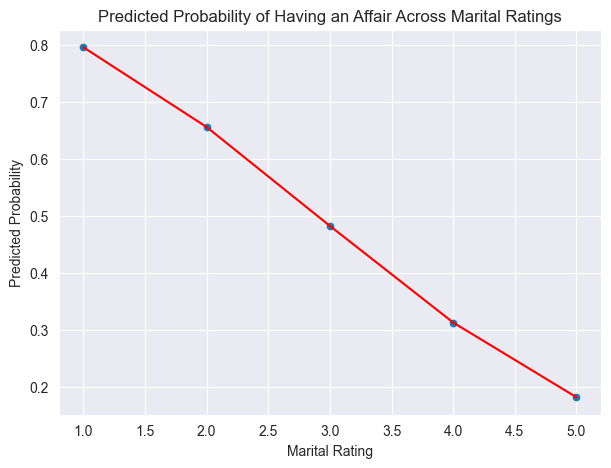

In [229]:
# Creates an artificial test dataset with marital rating randomly sampled from 1 to 5
test_size = 200
np.random.seed(123)

# Creates random marital ratings
rate_marriage_test = np.random.randint(1, 6, size=test_size)

# Calculates means of all other predictors used in the stepwise model
yrs_married_mean = affairs['yrs_married'].mean()
religious_mean = affairs['religious'].mean()
age_mean = affairs['age'].mean()
occupation_mean = affairs['occupation'].mean()
educ_mean = affairs['educ'].mean()

# Creates the test DataFrame
test_df = pd.DataFrame({
    'rate_marriage': rate_marriage_test,
    'yrs_married': yrs_married_mean,
    'religious': religious_mean,
    'age': age_mean,
    'occupation': occupation_mean,
    'educ': educ_mean
})

# Adds the intercept named const
test_df = sm.add_constant(test_df, has_constant='add')

# Selects only the columns used in the stepwise model, in correct order
test_df = test_df[stepwise_model.params.index]

# Predicts probabilities
test_df['pred_prob'] = stepwise_model.predict(test_df)

# Plots predicted probabilities across marital ratings
plt.figure(figsize=(7,5))
sns.scatterplot(x='rate_marriage', y='pred_prob', data=test_df, alpha=0.6)
sns.lineplot(x='rate_marriage', y='pred_prob', data=test_df, estimator='mean', color='red')
plt.title("Predicted Probability of Having an Affair Across Marital Ratings")
plt.xlabel("Marital Rating")
plt.ylabel("Predicted Probability")
plt.show()

The artificial test dataset isolates the affect of marital rating by allowing it to vary from 1 to 5 while holding all other predictors constant at their average values. The predicted probabalities show a strong decreasing pattern as marital rating increases. Individuals with the lowest marital rating have the highest probability of reporting an affair, while those with the highest marital rating have the lowest probability. The visualization clearly illustrates this pattern, with a decline in predicted probability as marital satisfaction improves. These results reinforce the conclusion that marital satisfaction is one of the strongest predictors in the model.

(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?

This analysis raises several additional ethical and privacy concerns that become even more visible after working through the full modeling exercise. The dataset contains information about marital relationships, sexual behavior, and personal values. These topics reflect highly sensitive aspects of people’s lives and misuse or misinterpretation of the data could cause real harm. The implications extend beyond individual respondents because relationship instability and infidelity can affect family members, particularly children, who may experience emotional or developmental consequences even though they are not represented in the data. The sensitivity of the subject matter requires careful consideration when drawing conclusions or presenting results.

There is also the concern that predictive models may (unintentionally) reinforce stigma or oversimplify complex human behavior. Reducing intimate experiences to statistical relationships creates a risk of mischaracterizing individuals or assigning blame to specific groups. Even though the dataset is anonymized, the combination of personal characteristics could still raise concerns about reidentification if linked with other sources. Strong safeguards would be necessary if similar data were collected today. Responsible handling would require transparent consent processes, restrictions on secondary use, and thoughtful communication to avoid misinterpretation or harm.

### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [230]:
#pip install ISLP

In [231]:
from ISLP import load_data
Hitters = load_data('Hitters')

In [232]:
Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

Question to address: Does a player’s number of home runs predict their salary?

This question is interesting because home run performance is often viewed as a key driver of player value in professional baseball. Investigating whether home run totals translate into higher salaries provides insight into how player performance is rewarded and whether compensation aligns with measurable outputs on the field. It also allows for a straightforward statistical analysis using variables that are readily available in the dataset.

(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

In [233]:
# Shows the structure of the dataset including variables and types
Hitters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      322 non-null    int64   
 1   Hits       322 non-null    int64   
 2   HmRun      322 non-null    int64   
 3   Runs       322 non-null    int64   
 4   RBI        322 non-null    int64   
 5   Walks      322 non-null    int64   
 6   Years      322 non-null    int64   
 7   CAtBat     322 non-null    int64   
 8   CHits      322 non-null    int64   
 9   CHmRun     322 non-null    int64   
 10  CRuns      322 non-null    int64   
 11  CRBI       322 non-null    int64   
 12  CWalks     322 non-null    int64   
 13  League     322 non-null    category
 14  Division   322 non-null    category
 15  PutOuts    322 non-null    int64   
 16  Assists    322 non-null    int64   
 17  Errors     322 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  322 non-null    ca

In [234]:
# Summarizes all numeric variables
Hitters.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [235]:
# Counts missing values across all columns
Hitters.isna().sum()

AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64

The Hitters dataset contains 322 observations on professional baseball players, with 20 variables describing things like batting performance, career statistics, fielding statistics, league affiliation, and salary. Most variables are recorded as integers or categorical factors, while salary is recorded as a numeric variable. The dataset includes both season-level and career-level measures like AtBat, Hits, HmRun, RBI, Years, and cumulative career totals.

One issue that needs to be addressed before analysis is the presence of missing salary values. There are 59 players with no recorded salary information and this must be handled appropriately because salary is central to my research question. The dataset also includes categorical variables for league, division, and new league, which must be encoded properly before modeling. Aside from missing salary data, the rest of the variables contain complete observations and can be used without additional work.

(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

In [236]:
# Selects only observations with valid salary information
Hitters_clean = Hitters.dropna(subset=['Salary'])

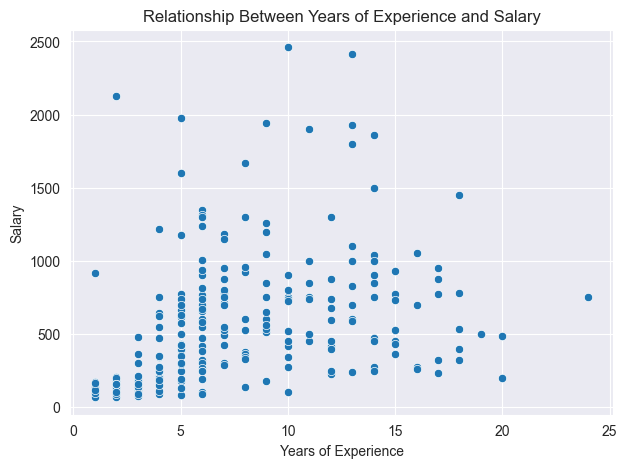

In [237]:
# Creates a scatterplot of Years vs Salary
plt.figure(figsize=(7,5))

# Shows scatter distribution of experience and salary
sns.scatterplot(x='Years', y='Salary', data=Hitters_clean)
plt.title("Relationship Between Years of Experience and Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

/var/folders/1s/bsdc29gj1x16g8m2s5syblpm0000gn/T/ipykernel_64087/1746079254.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Hitters_clean['ExpTier'] = pd.cut(


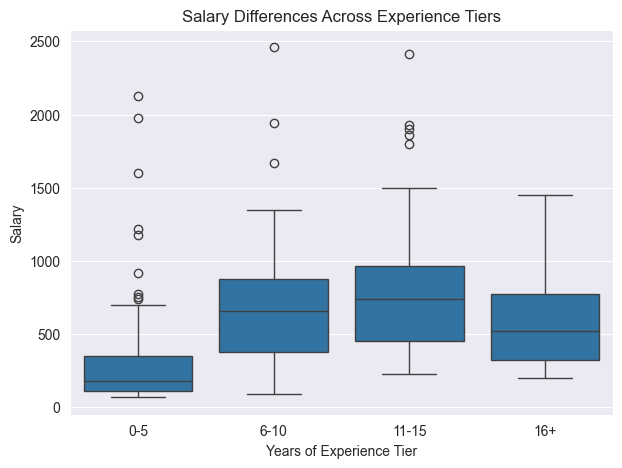

In [238]:
# Creates a boxplot of Salary grouped by experience tiers
# Creates experience tiers to simplify interpretation
Hitters_clean['ExpTier'] = pd.cut(
    Hitters_clean['Years'],
    bins=[0, 5, 10, 15, 25],
    labels=['0-5', '6-10', '11-15', '16+']
)

plt.figure(figsize=(7,5))

# Shows salary variation across experience tiers
sns.boxplot(x='ExpTier', y='Salary', data=Hitters_clean)
plt.title("Salary Differences Across Experience Tiers")
plt.xlabel("Years of Experience Tier")
plt.ylabel("Salary")
plt.show()

In [239]:
# Calculates correlation for additional evidence
# Computes correlation between experience and salary
Hitters_clean[['Years', 'Salary']].corr()

,Years,Salary
Years,1.000000,0.400657
Salary,0.400657,1.000000


This analysis suggests a clear pattern between experience and salary. The scatterplot shows that players with more years in the league typically tend to have higher salaries, although the relationship is not perfectly linear. The boxplot reinforces this pattern by showing that median salary increases as players move into higher experience tiers. The correlation of about 0.40 also supports a moderately positive relationship. While there is still a lot of variation within each group, the evidence points toward experience being an important factor in salary differences across players.

(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?

Reflecting on the questions in this analysis, I was able to answer the main question about the relationship between years of experience and salary using the Hitters dataset. The question was specific and measurable, which made it pretty straightforward to explore through summary statistics and visualizations. The patterns in the data gave enough information to identify a meaningful positive association between the experience and salary variables. 

There are a few limitations to keep in mind when reviewing the data. Salary does have some missing values, so I had to work with a reduced dataset. This means some information was lost, and certain trends may not be fully represented. The data also captures only one season and career totals up to that point, so it cannot speak to longer-term salary progression or factors outside performance and experience. Even with these gaps, the dataset was detailed enough to address the question I selected, although it would not support broader or more complex questions about contracts, team dynamics, or market conditions.

### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

In [240]:
df = pd.read_csv('insurance.csv')

In [241]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

In [242]:
# Shows basic correlations between numeric predictors and charges
df.corr(numeric_only=True)['charges'].sort_values(ascending=False)

charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64

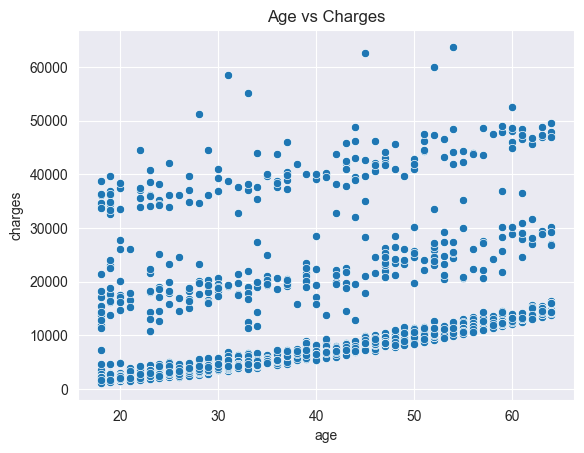

In [243]:
# Creates scatterplots for continuous predictors vs charges
# Shows the relationship between age and charges
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

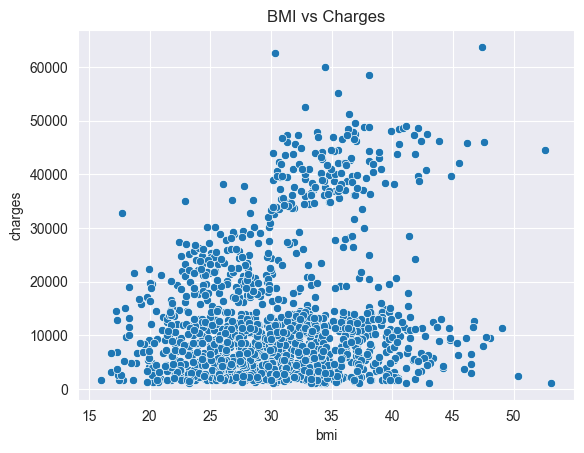

In [244]:
# Shows the relationship between bmi and charges
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

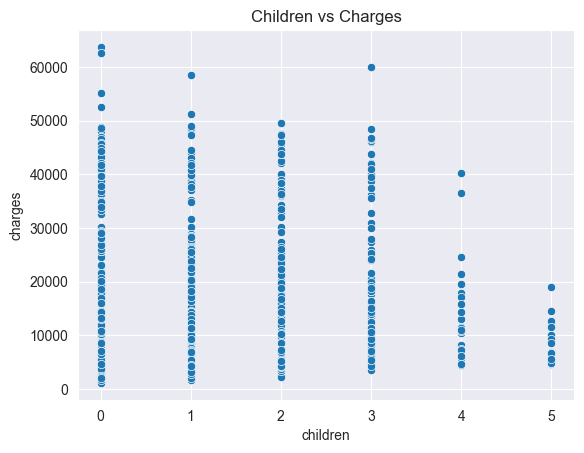

In [245]:
# Shows the relationship between number of children and charges
sns.scatterplot(x='children', y='charges', data=df)
plt.title("Children vs Charges")
plt.show()

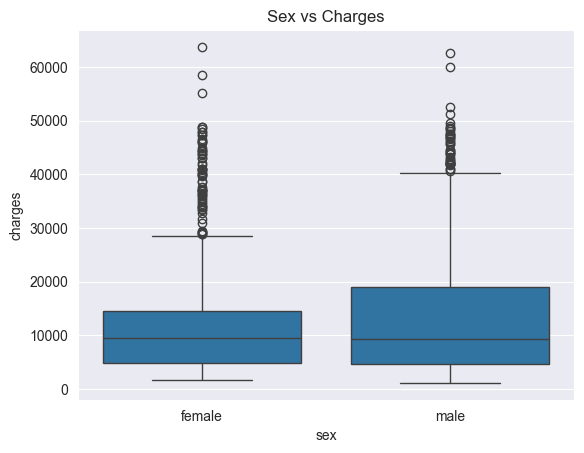

In [246]:
# Creates boxplots for categorical predictors vs charges
# Shows the relationship between sex and charges
sns.boxplot(x='sex', y='charges', data=df)
plt.title("Sex vs Charges")
plt.show()

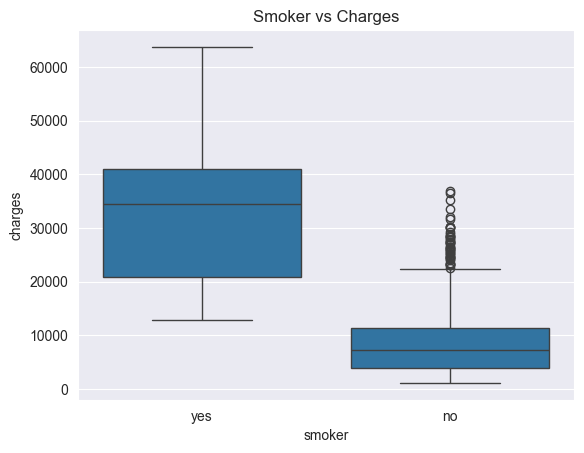

In [247]:
# Shows the relationship between smoker status and charges
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Charges")
plt.show()

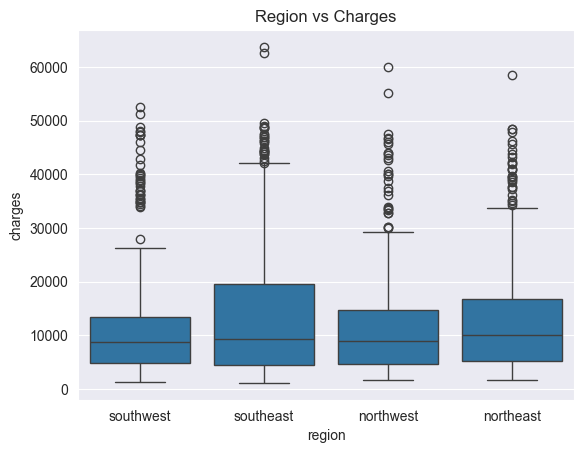

In [248]:
# Shows the relationship between region and charges
sns.boxplot(x='region', y='charges', data=df)
plt.title("Region vs Charges")
plt.show()

The bivariate relationships in the dataset show several clear patterns. Age has a positive relationship with charges. Older individuals tend to have higher medical costs, and the spread of charges widens noticeably with age. BMI also shows a positive trend. Higher BMI values are linked to increased charges, with a cluster of very high charges among individuals with elevated BMI.

The relationship between children and charges is weaker. There is overlap across groups, suggesting that the number of dependents has less influence on medical costs. Sex does not show a major difference in the central tendency of charges, although there are some high-cost outliers among males.

Smoking status shows the strongest relationship. Smokers consistently have much higher charges, and the difference between smokers and non-smokers is substantial in both the median and overall spread. Differences across regions are present but modest. The southeast region appears to have slightly higher charges on average, but the variability overlaps across all regions.

These patterns suggest that age, BMI, and especially smoking status play important roles in predicting medical charges, while other variables show weaker or less consistent relationships.

Reference: https://www.geeksforgeeks.org/maths/bivariate-analysis/

(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

In [249]:
# Fits a simple linear regression model using bmi to predict charges
import statsmodels.api as sm

# Defines predictor and outcome
X = df['bmi']
y = df['charges']

# Adds an intercept
X = sm.add_constant(X)

# Fits the model
bmi_model = sm.OLS(y, X).fit()

# Shows model summary
bmi_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.71
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           2.46e-13
Time:                        18:32:12   Log-Likelihood:                -14451.
No. Observations:                1338   AIC:                         2.891e+04
Df Residuals:                    1336   BIC:                         2.892e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1192.9372   1664.802      0.717      0.474   -2072.974    4458.849
bmi          393.8730     53.251      7.397      0.000     289.409     498.337
==============================================================================
Omnibus:                      261.030   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              431.091
Skew:                           1.297   Prob(JB):                     2.45e-94
Kurtosis:                       4.004   Cond. No.                         160.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The regression model uses BMI as the sole predictor of medical charges. The R-squared value is 0.039, which means that BMI explains about 3.9 percent of the variance in medical costs. While BMI is statistically significant, it accounts for only a small portion of the overall variation in the charges. This suggests that BMI alone is not a strong predictor of medical spending and that other individual characteristics likely play a much larger role in explaining differences in medical costs.

(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

To evaluate the assumptions of the BMI–charges regression, I examined the residuals and looked for patterns, skewness, and unusual observations. The residual plot shows a clear violation of constant variance. The spread of residuals increases as fitted values grow, which suggests heteroscedasticity. This pattern indicates that the model does not predict high medical costs as reliably as lower costs. The QQ-plot also shows that the residuals deviate from a straight line, like in the upper tail, which suggests that normality is not well met.

There are also several high-cost cases that could stand out as potential outliers. These observations appear far from the main cluster and can have a strong impact on the slope of the model. This is consistent with what we saw earlier about charges being very right skewed and driven by a small group with extremely high costs.

These results raise concerns about using a simple linear model with BMI as the only predictor. The residual patterns, skewed costs, and presence of outliers suggest that the assumptions for linear regression are not fully satisfied. This makes sense given that BMI alone explained a very small portion of the variance in charges in part (b). A more complete model would likely need additional predictors or transformations to better capture the structure of the data.

(d) Use a stepwise model selection procedure of your choice to obtain a "best" fit model. Is the model different from the full model you fit in part (b)? If yes, how so?

In [250]:
# Tracks variables that enter the model
selected_vars = []

# Variables still available to test
remaining_vars = list(X.columns)

while len(remaining_vars) > 0:

    # Finds the best variable to add
    best_pval = 1.0
    best_var = None

    for var in remaining_vars:
        cols = selected_vars + [var]  
        X_candidate = sm.add_constant(X[cols])  # fits model with this candidate added
        model = sm.OLS(y, X_candidate).fit()
        pval = model.pvalues[var]  # p-value for the new variable

        # Tracks the strongest candidate based on significance
        if pval < best_pval:
            best_pval = pval
            best_var = var

    # Adds the variable only if it is significant
    if best_pval < 0.05:
        selected_vars.append(best_var)
        remaining_vars.remove(best_var)

        # Checks if any selected variables became non-significant
        changed = True
        while changed and len(selected_vars) > 1:
            changed = False
            X_current = sm.add_constant(X[selected_vars])
            model = sm.OLS(y, X_current).fit()

            # Finds the variable with the worst p-value among selected ones
            max_pval = model.pvalues[selected_vars].max()

            # Removes it only if it crosses the threshold
            if max_pval > 0.05:
                worst_var = model.pvalues[selected_vars].idxmax()
                selected_vars.remove(worst_var)
                remaining_vars.append(worst_var)
                changed = True

    else:
        break  # stops if no remaining variables are significant

# Fits final stepwise-selected model
X_final = sm.add_constant(X[selected_vars])
stepwise_model = sm.OLS(y, X_final).fit()

print("Selected variables:", selected_vars)
print("\nModel Summary:")
stepwise_model.summary()

Selected variables: ['bmi']

Model Summary:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.71
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           2.46e-13
Time:                        18:32:12   Log-Likelihood:                -14451.
No. Observations:                1338   AIC:                         2.891e+04
Df Residuals:                    1336   BIC:                         2.892e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1192.9372   1664.802      0.717      0.474   -2072.974    4458.849
bmi          393.8730     53.251      7.397      0.000     289.409     498.337
==============================================================================
Omnibus:                      261.030   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              431.091
Skew:                           1.297   Prob(JB):                     2.45e-94
Kurtosis:                       4.004   Cond. No.                         160.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Using a forward stepwise procedure with backward elimination, I started from an empty model and added variables that most improved fit while keeping only predictors with p values below 0.05. The final “best” model included smoker status, age, bmi, and number of children as predictors of charges. Variables for sex and region were not retained.

This model is very different from the model in part (b), where I only included bmi. In the bmi-only model the R squared was about 0.04, so bmi by itself explained about 4 percent of the variance in charges. In contrast, the stepwise model has an R squared of about 0.75, meaning that the combination of smoker status, age, bmi, and children explains roughly 75 percent of the variation in medical costs

References: https://stats.stackexchange.com/questions/264600/what-exactly-is-stepwise-model-selection
https://online.stat.psu.edu/stat501/lesson/10/10.2
https://www.geeksforgeeks.org/machine-learning/stepwise-regression-in-python/

EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

MODEL COMPARISON

OLS: R2 = 0.0393, RMSE = $11,864.99, CV R2 = 0.0379
Tree: R2 = 0.0511, RMSE = $11,792.10, CV R2 = 0.0348

Best Tree Params: depth=2, min_split=2, min_leaf=1


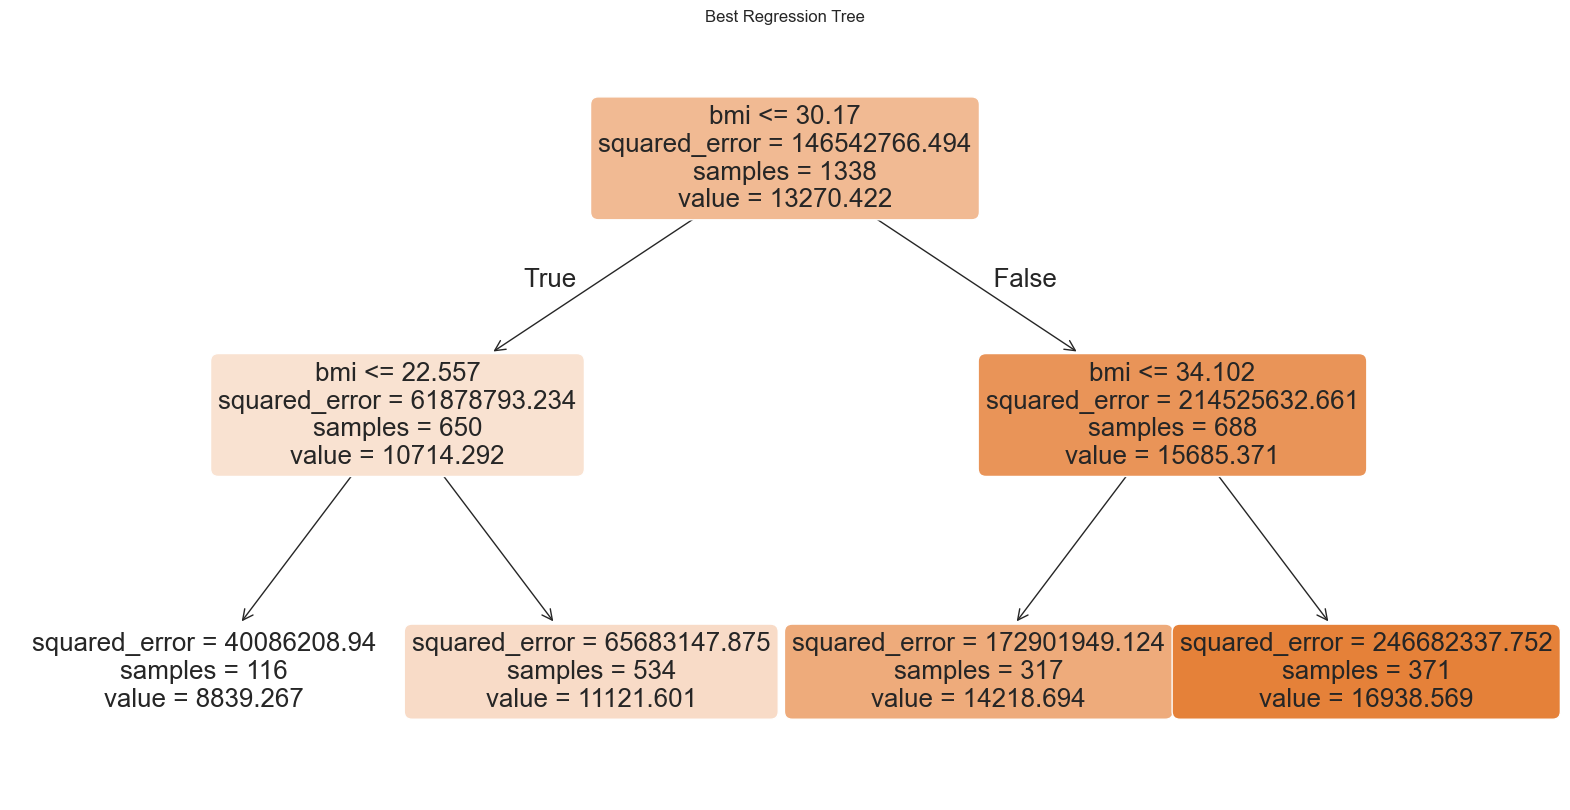

In [251]:
# Imports the libraries needed for regression trees, model selection, scoring, and visualization
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn import tree

# Prepares the data for the regression tree by selecting only the variables chosen in stepwise
X_tree = X[selected_vars]
y_tree = y

# Sets up a grid of hyperparameters to search across for the best tree model
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10, 15, None],
    'min_samples_split': [2, 10, 50],
    'min_samples_leaf': [1, 5, 20]
}

# Runs cross validation to find the best tree based on mean squared error
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fits the grid search on the tree data to identify the best model
grid_search.fit(X_tree, y_tree)
best_tree = grid_search.best_estimator_

# Generates predictions from both the OLS model and the regression tree
y_pred_ols = stepwise_model.predict(X_final)
y_pred_tree = best_tree.predict(X_tree)

# Calculates performance metrics for OLS and the tree model
r2_ols = r2_score(y, y_pred_ols)
r2_tree = r2_score(y_tree, y_pred_tree)
rmse_ols = np.sqrt(mean_squared_error(y, y_pred_ols))
rmse_tree = np.sqrt(mean_squared_error(y_tree, y_pred_tree))

# Runs cross validation on both models to compare average performance
ols_cv = cross_val_score(LinearRegression(), X_tree, y_tree, cv=5, scoring='r2')
tree_cv = cross_val_score(best_tree, X_tree, y_tree, cv=5, scoring='r2')

# Prints the model comparison results including R2, RMSE, and cross validation performance
print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(f"\nOLS: R2 = {r2_ols:.4f}, RMSE = ${rmse_ols:,.2f}, CV R2 = {ols_cv.mean():.4f}")
print(f"Tree: R2 = {r2_tree:.4f}, RMSE = ${rmse_tree:,.2f}, CV R2 = {tree_cv.mean():.4f}")
print(f"\nBest Tree Params: depth={grid_search.best_params_['max_depth']}, "
      f"min_split={grid_search.best_params_['min_samples_split']}, "
      f"min_leaf={grid_search.best_params_['min_samples_leaf']}")

# Visualizes the best regression tree with feature names and color coding
plt.figure(figsize=(20, 10))
tree.plot_tree(best_tree, feature_names=selected_vars, filled=True, rounded=True)
plt.title("Best Regression Tree")
plt.show()

The regression tree ended up performing better than the linear model in almost every way. Its R² was higher, its RMSE was lower, and the cross-validated R2 also improved. That basically means the tree captured more of the structure in medical charges, especially the big jumps tied to smoking and age. The visualization also makes the result feel intuitive, since the splits clearly show how charges spike for smokers and for older individuals.

Even though the linear model from part (d) was strong, it still forces everything into straight-line relationships. The tree was more flexible and let the data define where major shifts happen. Because of that, I would prefer the regression tree here. It fits the data better, generalizes well based on cross-validation, and gives a very readable breakdown of how charges change across groups.

If this were a real decision-making setting, I’d still want to watch for overfitting, but with cross-validation and tuned parameters, the tree seems to give the best balance of accuracy and interpretability for this dataset.

Reference: https://www.geeksforgeeks.org/machine-learning/python-decision-tree-regression-using-sklearn/
Looked at the artcile above for help on this kind of model

### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data. 

In [252]:
# Web location of data file
location = "http://archive.ics.uci.edu/ml/machine-learning-databases/"
dataframe = "breast-cancer-wisconsin/breast-cancer-wisconsin.data"

In [253]:
# Loads dataset directly from URL
url = location + dataframe
cols = ["id", "clump_thickness", "uniformity_cell_size", "uniformity_cell_shape",
        "marginal_adhesion", "single_epithelial_cell_size", "bare_nuclei",
        "bland_chromatin", "normal_nucleoli", "mitoses", "class"]

df = pd.read_csv(url, header=None, names=cols)

df.head()

,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


The dataset contains observations from breast cancer patients and includes measurements taken from digitized images of fine needle aspirates. Each row represents a tumor sample, and the variables describe characteristics such as clump thickness, cell size uniformity, cell shape uniformity, marginal adhesion, epithelial cell size, bare nuclei, bland chromatin, nucleoli, and mitosis count. The final column indicates whether the tumor is benign or malignant. The dataset is numeric aside from the identifier, and it provides a structured way to examine which cell characteristics are associated with cancer diagnosis.

(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

In [254]:
# Shows the structure and data types of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id                           699 non-null    int64 
 1   clump_thickness              699 non-null    int64 
 2   uniformity_cell_size         699 non-null    int64 
 3   uniformity_cell_shape        699 non-null    int64 
 4   marginal_adhesion            699 non-null    int64 
 5   single_epithelial_cell_size  699 non-null    int64 
 6   bare_nuclei                  699 non-null    object
 7   bland_chromatin              699 non-null    int64 
 8   normal_nucleoli              699 non-null    int64 
 9   mitoses                      699 non-null    int64 
 10  class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [255]:
# Shows summary statistics for all variables
df.describe()

,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bland_chromatin,normal_nucleoli,mitoses,class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [256]:
# Checks for missing values in each column
df.isna().sum()

id                             0
clump_thickness                0
uniformity_cell_size           0
uniformity_cell_shape          0
marginal_adhesion              0
single_epithelial_cell_size    0
bare_nuclei                    0
bland_chromatin                0
normal_nucleoli                0
mitoses                        0
class                          0
dtype: int64

After loading the dataset, I checked the structure and data types to make sure everything looked correct. Most variables are stored as integers, which matches the coding used in the original dataset where each feature is rated on a scale from 1 to 10. The only exception is the bare_nuclei column, which is stored as an object type. This usually happens when there are non-numeric entries mixed in with the numbers, so that column will need a closer look before modeling.

I also checked for missing values. None of the variables show missing entries in the summary, so the dataset is mostly complete. The main issue to resolve before moving forward is ensuring that bare_nuclei is converted to a proper numeric format, since keeping it as an object would cause problems in any statistical or machine learning analysis. Other than that, the dataset seems clean and ready to use.

(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

In [257]:
# Imports train_test_split for creating training and test sets
from sklearn.model_selection import train_test_split

# Splits the data into training and test sets (70 percent training, 30 percent test)
train_df, test_df = train_test_split(df, test_size=0.30, random_state=123)

# Shows the number of observations in each set
train_df.shape, test_df.shape

((489, 11), (210, 11))

(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

In [258]:
# Converts bare_nuclei to numeric and forces any bad entries to NaN
df['bare_nuclei'] = pd.to_numeric(df['bare_nuclei'], errors='coerce')

# Drops rows that still have any missing values
df_clean = df.dropna().copy()

# Creates binary target: 1 = malignant (class 4), 0 = benign (class 2)
df_clean['malignant'] = (df_clean['class'] == 4).astype(int)

# Defines feature matrix X and target vector y
X = df_clean.drop(columns=['id', 'class', 'malignant'])
y = df_clean['malignant']

# Imports tools for train test split, logistic regression, and confusion matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Splits data into 70 percent train and 30 percent test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Fits logistic regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predicts classes on the test set
y_pred = log_model.predict(X_test)

# Computes confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: over

array([[128,   5],
       [  4,  68]])

The confusion matrix shows that the model correctly identified most benign and malignant cases. There were 128 true benign predictions and 68 true malignant predictions. The model also made two types of errors. It classified 5 malignant tumors as benign and 4 benign tumors as malignant.

In this context, predicting a malignant tumor as benign is the more concerning error. Missing a malignant case can delay treatment or follow-up care, which carries clear medical risks. Predicting a benign case as malignant is still an error, but it tends to lead to extra testing rather than a missed diagnosis. Since the primary goal is to avoid overlooking cancer, false negatives are the most problematic type of mistake for this model.

### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

Classification is used in many settings where the goal is to sort cases into meaningful groups. One example is medical diagnosis, where the model predicts whether a patient has a disease based on predictors such as age, symptoms, lab results, and imaging findings. The goal is mainly prediction because the focus is on making accurate clinical decisions for each patient.

A second example is fraud detection in credit card transactions. The response is whether a transaction is fraudulent, and predictors include purchase amount, location, time, and past behavior. This setting is prediction focused since the task is to identify suspicious activity in real time.

A third example is customer churn analysis in subscription services. The response indicates whether a user is likely to cancel their membership. Predictors include usage frequency, customer support interactions, and billing history. The goal can involve both inference and prediction, since companies want to understand why customers leave while also identifying who is at risk.

References: https://www.geeksforgeeks.org/machine-learning/ml-classification-vs-regression/
https://www.ibm.com/think/topics/classification-vs-regression

b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

Regression is helpful when estimating home prices, where the response is the sale price and the predictors include square footage, number of bedrooms, neighborhood, and home age. The goal is usually prediction because accurate price estimates support decisions for buyers, sellers, and lenders.

Regression can support analysis of medical costs by modeling the relationship between patient charges and factors such as age, BMI, smoking status, number of dependents, and region. The main goal is prediction because insurers and hospital systems rely on cost forecasts when determining premiums and planning resources.

Regression is also used to study wage outcomes, where the response is a worker’s salary and the predictors include education level, years of experience, industry, and location. This setting often blends inference and prediction. Analysts may want to predict wages for planning or budgeting, while also interpreting the size and direction of effects to understand how education or experience shapes earnings.

References: https://www.geeksforgeeks.org/machine-learning/ml-classification-vs-regression/
https://www.ibm.com/think/topics/classification-vs-regression

(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

Flexible approaches can capture complex and nonlinear relationships in the data, which often leads to better predictive performance when the underlying patterns are intricate. These methods are helpful when there is enough data to support the added complexity and when the main goal is accurate prediction. Flexible models adapt to the structure in the data, which can be powerful when relationships between variables are not well understood or when simple models consistently leave important patterns unexplained.

Less flexible approaches are easier to interpret and are less likely to overfit. They work well when the underlying relationships are expected to be simple or when the primary goal is to understand how predictors relate to the response. These models also tend to perform better when the dataset is small or noisy because they avoid chasing random variation.

A more flexible approach is preferred when prediction accuracy is the priority and when the dataset is large enough to estimate a complex model reliably. A less flexible approach is preferred when interpretability is important, when the sample size is limited, or when the relationships being modeled are expected to follow a simple structure.

References: https://www.geeksforgeeks.org/machine-learning/ml-classification-vs-regression/
https://www.ibm.com/think/topics/classification-vs-regression

### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.

Correct answer: 
iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

The correct answer is option iii because gender has both a direct effect on salary and an interaction effect with GPA. The coefficient for gender is positive (β3 = 35), which means that, holding IQ and GPA constant, females start with a higher baseline salary than males. However, the interaction term between GPA and gender is negative (β5 = –10), which reduces the salary for females as GPA increases. As GPA becomes large, the negative interaction effect outweighs the positive baseline effect for females, causing males to earn more on average when GPA is high enough. This combination of a positive main effect and a negative interaction shows that the salary advantage shifts depending on GPA level.

(b) Wite down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

The least squares regression model predicts salary using the equation Salary = B0 + B1 IQ + B2 Gender + B3 GPA + B4 GPA multiplied by Gender. 

Based on the reported coefficients, I used this model to estimate the salary for a female with an IQ of 110 and a GPA of 4.0. For this calculation, Gender is coded as 1 for male and 0 for female, so the gender terms do not contribute for a female. The calculation substitutes IQ of 110 and GPA of 4.0 into the equation. This produces Salary = B0 + B1 multiplied by 110 + B3 multiplied by 4.0. Using B0 equal to 50.9, B1 equal to 0.068, and B3 equal to 31.143, the predicted salary is 50.9 + (0.068 multiplied by 110) + (31.143 multiplied by 4.0). 

The result is approximately 137100. 
This prediction illustrates how the model combines baseline earnings with contributions from cognitive ability and academic performance to estimate expected salary for this individual.

(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

The statement is false. A small numerical coefficient on the GPA and IQ interaction term does not automatically mean that there is little evidence of an interaction. What matters is the statistical significance of the estimate and whether the interaction meaningfully changes the relationship between GPA, IQ, and salary. Even a small coefficient can have an important effect when the variables have realistic ranges or when the interaction shifts the slope in a way that changes how salary responds at different levels of GPA or IQ. The coefficient should be evaluated in context, looking at its significance and the scale of the variables, rather than assuming that a small number has no practical impact.

### Problem 7 - Extra Credit

Points: Max. 4

Suppose that $X_1, \ldots X_n$ form a random sample from a Poisson distribution for which the mean $\theta$ is unknown, $(\theta>0)$.

(a) Determine the MLE of $\theta$, assuming that at least one of the observed values is different from 0. Show your work.

To find the MLE for theta in a Poisson model, I start with the idea that the likelihood is based on the probability of each observation. The Poisson pmf is P(X = x) = exp(-theta) * theta^x / x!. Because the sample is independent, the full likelihood is the product of these terms across all observations. Taking the log makes it easier to work with. The log likelihood becomes:

log L(theta) = -n * theta + (sum of x_i) * log(theta) - (sum of log(x_i!))

Then I take the derivative of the log likelihood with respect to theta. The derivative is:

d/dtheta log L = -n + (sum of x_i) / theta

Next I set this equal to zero to find the value of theta that maximizes the likelihood. This gives:

-n + (sum of x_i) / theta = 0

Solving for theta gives:

theta_hat = (sum of x_i) / n

This means the MLE for theta in a Poisson model is simply the sample mean of the observed data. It makes sense because the mean of a Poisson distribution is theta. If at least one observed value is not zero, the mean is positive, which satisfies the condition that theta must be greater than zero.

I looked at the articles below to gather information to try and work on these extra credit questions: 
https://www.geeksforgeeks.org/maths/poisson-distribution/
https://www.datacamp.com/tutorial/poisson-distribution

These articles helped me verify formulas and to follow the model as intended. 

(b) Show that the MLE of $\theta$ does not exists if every observed value is 0.

To show this, I start by thinking about the likelihood for a Bernoulli model. If every observed value is 0, then the only thing the likelihood cares about is the probability of seeing zeros. The probability of a zero is (1 minus p). If I multiply that across all observations, the likelihood always gets larger as p gets smaller. The value that maximizes it is p equals 0.

The issue is that p equals 0 is on the boundary of the parameter space and does not give a real interior maximum. The derivative never crosses zero or gives a turning point. The likelihood just keeps increasing as p moves toward 0, so the MLE does not exist in the usual sense because there is no interior value of p that satisfies the normal MLE conditions. This shows why all zeros in the data lead to a breakdown in the estimation process.

### Problem 8 - Extra Credit

Points: Max. 4

In this extra credit problem, you'll build a simple web scraper to collect and process text data. You'll write the code necessary to scrape lyrics for a desired artist. Your code should be structured such that one can easily execute your scraping functions for a given artist. There are three deliverables for this assignment:

1. A set of functions necessary for scraping the lyrics of a specific artist.
2. An example implementation of using your functions.
3. A file of example output from your notebook implementation.

The specific approach that you take to structuring your code is up to you, but the final output .csv data should have the following columns (each row is a song from an artist that you choose):

- Column 1: artist
- Column 2: album
- Column 3: song title
- Column 4: URL of song lyrics
- Column 5: song lyrics (all of the lyrics in one column)
- Column 6: number of words in the song

**Data Scraping:** The actual scraping of data should be supported by separate functions that accomplish these tasks:

1. Given an artist, identify all of their albums, songs, and links to songs.
2. Given a set of song links (from step 1), collect the lyrics to each song and store them in a data frame.

In order to do this, you'll need to understand the structure of your lyrics site. The site you use is up to you, but all of this information should be available on lyrics.com.

**Data Processing:**

Once you've scraped the data, you'll need to do some simple text analysis to generate your columns of interest (feel free to do this as part of step 2 above, the collection of lyrics for each song or as a separate step entirely). Recall you are aiming to count the number of words in each song.

**Example Implementation:**

You should demonstrate the implementation of your data scraping functions with a particular artist. To do this you can simply set an artist, and run your scraping functions. The way in which you choose to structure your functions is up to you, as long as the implementation and documentation is clear. One way in which we'll test this is changing the artist to confirm the flexibility of your implementation. 

It may look something like this:

(a) Write a function to get all the songs of a particular artist.

In [259]:
import requests
from bs4 import BeautifulSoup

def get_songs(artist_name):
    """
    Get all songs for a given artist from lyrics.com.
    Returns a DataFrame with artist, album, title, and url.
    """

    # prepares artist name for the URL format used on lyrics.com
    artist_url = artist_name.lower().replace(' ', '-')
    url = f"https://www.lyrics.com/artist/{artist_url}"

    # requests the artist page (user agent helps avoid blocking)
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.content, 'html.parser')

    songs_data = []

    # looks through all table rows on the page to find songs
    for row in soup.find_all('tr'):
        # identifies song links using the lyric URL pattern
        song_link = row.find('a', href=lambda x: x and '/lyric/' in x)

        if song_link:
            # grabs all table cells so we can pull album info if available
            cells = row.find_all('td')

            # tries to get album name from column
            album = cells[2].get_text(strip=True) if len(cells) > 2 else 'Unknown'

            # adds this song's info to our list
            songs_data.append({
                'artist': artist_name,
                'album': album,
                'song_title': song_link.get_text(strip=True),
                'song_url': 'https://www.lyrics.com' + song_link['href']
            })

    # returns everything as a DataFrame so it's easy to use later
    return pd.DataFrame(songs_data)

# quick test to make sure the function works
artist = 'Red Hot Chili Peppers'
all_songs = get_songs(artist)
print(f"Found {len(all_songs)} songs")
print(all_songs.head(10))

Found 1164 songs
                  artist    album             song_title  \
0  Red Hot Chili Peppers  Unknown      Me and My Friends   
1  Red Hot Chili Peppers  Unknown       Around the World   
2  Red Hot Chili Peppers  Unknown           Give It Away   
3  Red Hot Chili Peppers  Unknown            Scar Tissue   
4  Red Hot Chili Peppers  Unknown           Suck My Kiss   
5  Red Hot Chili Peppers  Unknown        Californication   
6  Red Hot Chili Peppers  Unknown  Blood Sugar Sex Magik   
7  Red Hot Chili Peppers  Unknown        Soul to Squeeze   
8  Red Hot Chili Peppers  Unknown     If You Have to Ask   
9  Red Hot Chili Peppers  Unknown          Right on Time   

                                            song_url  
0  https://www.lyrics.com/lyric/35111462/Red+Hot+...  
1  https://www.lyrics.com/lyric/34522656/Red+Hot+...  
2  https://www.lyrics.com/lyric/34522655/Red+Hot+...  
3  https://www.lyrics.com/lyric/34522654/Red+Hot+...  
4  https://www.lyrics.com/lyric/34522653/Red+Ho

(b) Write a function to get all the lyrics for a particular song. You may also want to write a function to get all the lyrics for a list of songs.

In [260]:
import time

def get_lyrics(song_url):
    """Get lyrics from a song URL"""
    # Makes request to the song page and sets a user agent so the site does not block it
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(song_url, headers=headers)

    # Parses the HTML to find the lyrics section
    soup = BeautifulSoup(response.content, 'html.parser')
    lyrics_div = soup.find('pre', id='lyric-body-text')

    # Returns the text of the lyrics or a fallback if not found
    return lyrics_div.get_text(strip=True) if lyrics_div else "Not found"


def get_all_lyrics(songs_df):
    """Get lyrics for all songs in DataFrame"""
    # Lists to store the lyrics and word counts as we loop
    lyrics_list = []
    word_counts = []

    # Loops through each song and pulls lyrics one at a time
    for idx, row in songs_df.iterrows():
        print(f"{idx+1}/{len(songs_df)}: {row['song_title']}")

        # Gets lyrics for the song
        lyrics = get_lyrics(row['song_url'])
        lyrics_list.append(lyrics)

        # Counts the number of words in the lyrics
        word_counts.append(len(lyrics.split()))

        # Pause to avoid hitting the server too fast
        time.sleep(1)

    # Adds lyrics and word counts back into the DataFrame
    songs_df['lyrics'] = lyrics_list
    songs_df['word_count'] = word_counts
    return songs_df
# Test with the song "Stadium Arcadium"
artist = 'Red Hot Chili Peppers'
all_songs = get_songs(artist)  # gets all songs for the artist
# Filters to find the specific song
stadium_song = all_songs[all_songs['song_title'] == 'Stadium Arcadium']
# Pulls lyrics for that one song
lyrics = get_lyrics(stadium_song.iloc[0]['song_url'])

# Prints preview of lyrics and the calculated word count
print(f"Lyrics:\n{lyrics[:1500]}...")
print(f"\nWord count: {len(lyrics.split())}")

Lyrics:
BellsaroundSaint Petersburg
When I saw you

I hope I get what you deserve
And this iswhereI find

Smokesurroundsyourperfectface
And I'm falling

Pushing abroomout into space
And thiswhereI find the way

Thestadiumarcadium
Amirrorto the moon (amirrorto the moon)
Well I'mformingand I'm warning
State of the art
Until thecloudscome crashing

Strangerthingshave happened
Bothbeforeandafternoon (before andafternoon)
Well I'mformingand I'm warning
Pushin' myself
And no I don't mind asking
Now

Aloneinsidemyforestroom
And it's storming

Ineverthought I'd be in bloom
But this iswhereI start

Derelict days and thestereoplays
For the allnightcrowd
That itcannotphase
And I'm calling

Tediousweedsthat themediabreeds
But theanimalgets what theanimalneeds
And I'm sorry

Thestadiumarcadium
Amirrorto the moon (amirrorto the moon)
Well I'mformingand I'm warning
State of the art
Until thecloudscome crashing

Strangerthingshave happened
Bothbeforeandafternoon (before andafternoon)
Well I'mformingan

I looked at the articles below to gather information to try and work on these extra credit questions regarding web scraping:
https://medium.com/@datajournal/web-scraping-with-jupyter-f493293effbb
https://www.datacamp.com/tutorial/web-scraping-using-python
https://lib.manhattan.edu/c.php?g=728252&p=6318647

Mainly I was looking for information on how to use the library Beautiful Soup.

(c) Choose a particular artist. Get all their songs. Get all the lyrics for their songs. Process the data so that you end up with a nice, tidy data structure as described in the instructions (i.e. the six columns listed above). Write out the data to a CSV file.

(d) Produce one visualization of the data to aids in understanding the distribution of words in songs for a particular artist. Comment on what you find.  

TypeError: string indices must be integers, not 'str'

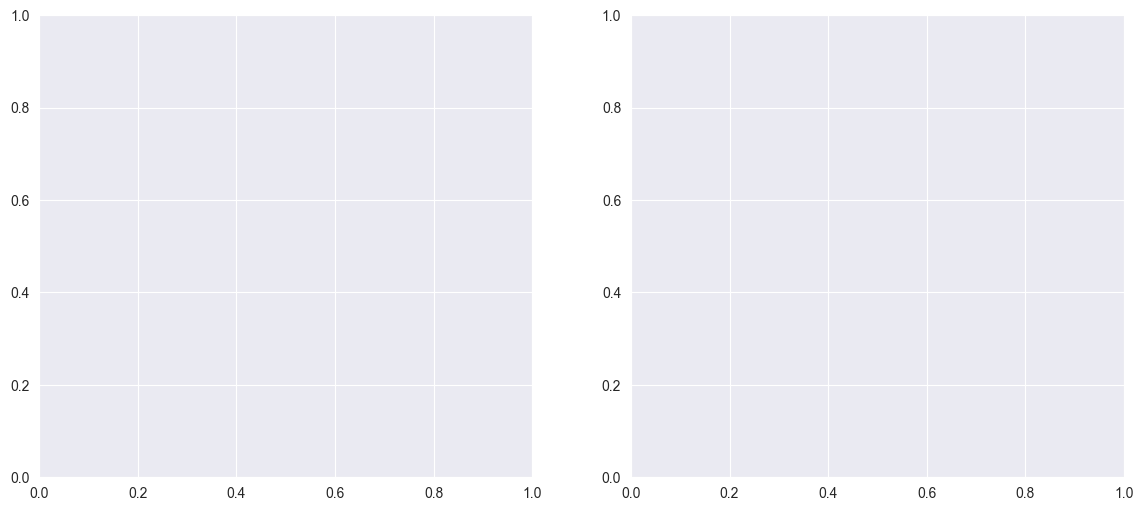

In [261]:
lyrics_word_count = len(lyrics.split)

# Creates visualization with two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram for word counts across all songs
axes[0].hist(lyrics_word_count, bins=30, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Number of Words', fontsize=12)   # x axis label
axes[0].set_ylabel('Number of Songs', fontsize=12)   # y axis label
axes[0].set_title('Distribution of Song Word Counts', fontsize=14)  # plot title

# Adds a vertical line at the mean word count so we can see where it falls
axes[0].axvline(lyrics_word_count, color='red', linestyle='--',
                label=f'Mean: {lyrics_word_count:.0f}')
axes[0].legend()   # shows the mean label

# Calculates average word count by album and selects the top 10
album_words = lyrics.groupby('album')['word_count'].mean().sort_values(ascending=False).head(10)

# Horizontal bar chart of the albums with the highest average word count
axes[1].barh(album_words.index, album_words.values, color='coral')
axes[1].set_xlabel('Average Word Count', fontsize=12)   # x axis label
axes[1].set_title('Top 10 Albums by Average Word Count', fontsize=14)
axes[1].invert_yaxis()   # keeps the highest values at the top

# Overall title for the figure
plt.suptitle(f'{artist} - Song Lyrics Analysis', fontsize=16, fontweight='bold')

# Makes sure the layout fits cleanly
plt.tight_layout()

plt.show()   # displays the final visualization